<a href="https://colab.research.google.com/github/athulv2001/sales-trend-analysis/blob/main/Sales_Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Trend Analysis

## Business Problem
A company wants to understand weekly sales performance to identify growth trends, peak demand periods, and weeks with declining sales.

The goal of this analysis is to:
- Calculate average weekly sales
- Identify highest and lowest sales weeks
- Detect sales trends
- Flag above-average performance weeks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    "week": [1,2,3,4,5,6,7,8],
    "sales": [200, 220, 210, 250, 260, 240, 280, 300]
}
df = pd.DataFrame(data)
df

,week,sales
0,1,200
1,2,220
2,3,210
3,4,250
4,5,260
5,6,240
6,7,280
7,8,300


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   week    8 non-null      int64
 1   sales   8 non-null      int64
dtypes: int64(2)
memory usage: 260.0 bytes


In [4]:
df.describe()

,week,sales
count,8.00000,8.000000
mean,4.50000,245.000000
std,2.44949,34.641016
min,1.00000,200.000000
25%,2.75000,217.500000
50%,4.50000,245.000000
75%,6.25000,265.000000
max,8.00000,300.000000


In [5]:
df.isnull().sum()

,0
week,0
sales,0


In [6]:
avg_sale = df['sales'].mean()
print("Average Sales:", avg_sale)


Average Sales: 245.0


In [7]:
df["above_avg"] = df['sales'] > avg_sale
df

,week,sales,above_avg
0,1,200,False
1,2,220,False
2,3,210,False
3,4,250,True
4,5,260,True
5,6,240,False
6,7,280,True
7,8,300,True


In [8]:
df["sales_report"] = df['sales'].diff()
df

,week,sales,above_avg,sales_report
0,1,200,False,NaN
1,2,220,False,20.0
2,3,210,False,-10.0
3,4,250,True,40.0
4,5,260,True,10.0
5,6,240,False,-20.0
6,7,280,True,40.0
7,8,300,True,20.0


In [9]:
df["sales_report"] = df['sales'].diff().fillna(0)
df


,week,sales,above_avg,sales_report
0,1,200,False,0.0
1,2,220,False,20.0
2,3,210,False,-10.0
3,4,250,True,40.0
4,5,260,True,10.0
5,6,240,False,-20.0
6,7,280,True,40.0
7,8,300,True,20.0


In [10]:
df["trend"] = "stable"
df.loc[df["sales_report"] > 0, "trend"] = 'Growth'
df.loc[df["sales_report"] < 0, "trend"] = 'Decline'
df

,week,sales,above_avg,sales_report,trend
0,1,200,False,0.0,stable
1,2,220,False,20.0,Growth
2,3,210,False,-10.0,Decline
3,4,250,True,40.0,Growth
4,5,260,True,10.0,Growth
5,6,240,False,-20.0,Decline
6,7,280,True,40.0,Growth
7,8,300,True,20.0,Growth


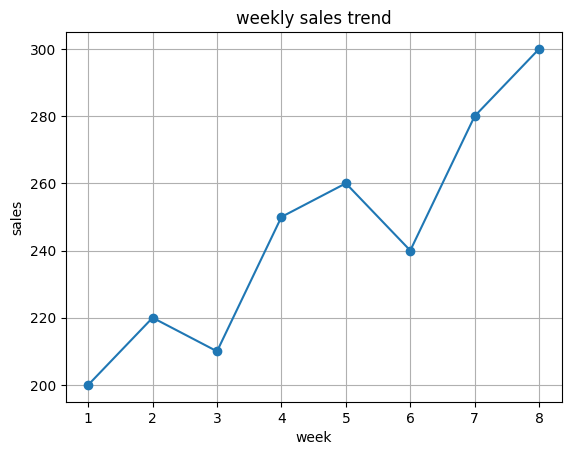

In [11]:
plt.plot(df["week"], df["sales"], marker="o")
plt.title("weekly sales trend")
plt.xlabel("week")
plt.ylabel("sales")
plt.grid(True)
plt.show()

## Key Insights

1. The average weekly sales were approximately **245 units**.

2. The highest sales occurred in **week 8**, reaching **300 units**.

3. The largest increases in sales happened in **week 4** and **week 7**, where sales grew by **40 units** compared to the previous week.

4. Sales declined in **week 3** and **week 6**, indicating temporary drops in demand.

5. Overall, the sales trend shows **steady growth toward the later weeks**, suggesting increasing customer demand.